<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'> REINFORCEMENT LEARNING </h2>
</div>

> It’s a type of machine learning and part of AI	
> Learning of what to do and how to map situation to action within a specific context	
> End result is to maximize the performance	
> Here learner is not told which action to take, but instead must discover which action will yield max rewards.	


### Reinforcement Learning Alg approach:			
			
- 1. To  find optimal path with high rewards is the approach in RL, we follow standard approach		
- 2. 1st We will input R matrix  based on the matrix flow with size=max no of steps/paths. which we have Y axis index are current steps, X axis index are Next step in matrix.  or we can write loop to create R matrix, done in case study		
- 3. Then build same size, Q matrix with all value as 0		
- 4. Then set gamma value, we set as .08, this behaves as deduction value		
- 5. Then write a function(available_actions), if we input current step, it will give next possible step( which is X axis index values)		
- 6. Then write a function(sample_next_action), above available_actions if we multiple o/p it provides random one steps(one X axis index)		
- 7. Then write a function(update), This function updates the Q matrix according to the path selected and the Q learning algorithm "Bellman's Equation"		
- 8. Call all these function in sequence for multiple times to update Q		
- 9. Normalize the Q matrix value, means devide by its max value and multiply by 100, so that it will give all rewards within 100, 100 is final steps aprroching path reward		
- 10. Write a while loop to find optimal path till it reaches final step. This provides optimal path.		


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

## MODULE 12 - REINFORCEMENT LEARNING

##  Case Study 
#### Domain –Logistics

#### focus –Optimal path

#### Business challenge/requirement:
- BluEx is a leading logistics company in India.  
- It's known for efficient delivery of packets to customers.  
- However BluEx is facing a challenge where its vandrivers are taking a suboptimal path for delivery.  
- This is causing delays and higher fuel cost.
- You as ML expert have to create a ML model using Reinforcement Learning so that efficient path is found through the program. 

#### Key issues:
    Data has lotsof attributes and classification could be tricky

#### Considerations:
- Reinforcement Learning is tricky,so the expectation is to come up with sample flow and full-fledged implementation will be done by team later

#### Data volume-None. 
- Sample data is hard coded in the program

#### Additional information-NA

#### Business benefits
- Up to 15% fuelcost can be saved by taking optimal path


<div class="alert alert-info" style="background-color:#001b63; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>METHOD 1  </h2>
</div>
- We have built our own R  matrix for this issue. We need to find Best approach

- Updated Q matrix will have reward values in all R matrix related positions only, then our next step will finds optimal path with max reward from Q

## 1. Data Set  -  R Matrix : 
#### Create Matrix for number of points in the graph. In this case we considered 6 dimention matrix.

In [68]:
import numpy as np
#Here we have only built Or hardcoded R mtrix , but in below edu sol, used for loop to build R matrix and assign goal points, 
#now we chose goal point=100
# here 100 means its final desinatin point, 0 means path is there , -1 means no path
# R matrix

R     =        np.matrix([ [-1,0,0,-1,-1,-1],
                           [0,-1,-1,0,-1,-1],
                           [0,-1,-1,-1,0,-1],
                           [-1,0,-1,-1,0,100],
                           [-1,-1,0,0,-1,100],
                           [-1,-1,-1,0,0,100] ])


## 2. Q MATRIX

> zero value Q matrix

> Created Q matrix same size as R matrix with value to 0

In [69]:
# zero value Q matrix
# Created Q matrix same size as R matrix with value to 0
Q = np.matrix (np.zeros([6,6]))
print(Q)
# Gamma (learning parameter) deduction parameter
gamma = 0.8
# Initial state (Usually to be chosen at random)
initial_state = 0

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [70]:
# This function returns all available actions in the state given as # an argument
#This provides Column index value
# if we input current step, it will give next possible step( which is X axis index values)

def available_actions(state):
    current_state_row = R[state,]
    # all X axis index values, where matrix value >=0
    av_act = np.where(current_state_row >= 0)[1]
    return av_act
# Get available actions in the current state
available_act = available_actions(initial_state)
available_act

array([1, 2], dtype=int64)

* From initial state 0, possible states are 1,2

In [71]:
# This function chooses at random which action to be performed within the range of all the available actions
#This provides random Column index value
#above available_actions if we multiple o/p it provides random one steps(one X axis index)

def sample_next_action(available_actions_range):
    next_action = int(np.random.choice(available_act,1))
    return next_action
# Sample next action to be performed
action = sample_next_action(available_act)
action

1

* This gives random no one value from  multiple choice

In [72]:
# This function updates the Q matrix according to the path selected and the Q learning algorithm
def update(current_state, action, gamma):  
    max_index = np.where(Q[action,] == np.max(Q[action,]))[1]
    if max_index.shape[0] > 1:
        max_index = int(np.random.choice(max_index, size = 1))
    else:
        max_index = int(max_index)
    max_value = Q[action, max_index]   
    #Bellman's Equation: Q learning Formula
    # Q(State,next action) = R(State,next action) + Gamma * Max[Q(Next state, All action )]
    Q[current_state, action] = R[current_state, action] + gamma * max_value
    
update(initial_state,action,gamma)
print(Q)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


### 2.1 Update the Q matrix by calling above all function

In [73]:
# Train over 10 000 iterations(Re-iterate the # process above),
#To update Q matrix, run this steps many times

for i in range(10000):
    current_state = np.random.randint(0, int(Q.shape[0]))
    available_act = available_actions(current_state)
    action = sample_next_action(available_act)
    update(current_state,action,gamma)

#Final Q matrix
print(Q)

[[  0. 320. 320.   0.   0.   0.]
 [256.   0.   0. 400.   0.   0.]
 [256.   0.   0.   0. 400.   0.]
 [  0. 320.   0.   0. 400. 500.]
 [  0.   0. 320. 400.   0. 500.]
 [  0.   0.   0. 400. 400. 500.]]


### 2.2 Testing 
 - Finding the optimal path by this below while loop from Q matrix

In [75]:
#Testing for optimal path
current_state = 0 # here we considered starting path as 0
steps = [current_state]
while current_state != 5:  # This is final destination no
    # 1) np.where(Q[current_state,] --> this picks 1 complete row, if np.where(Q[2,] then 2nd row will be picked
    # 2) np.max(Q[current_state,]  --> this picks above row only and selects only max value in that row that is 64 col index 3
    # if 1)==2) then [1] returns its column index 3
    next_step_index = np.where(Q[current_state,] == np.max(Q[current_state,]))[1]
    if next_step_index.shape[0] > 1:
        next_step_index = int(np.random.choice(next_step_index, size=1))
    else:
        next_step_index = int(next_step_index)
    steps.append(next_step_index)
    current_state = next_step_index

# Print selected sequence of steps
print("Selected path:")
print(steps)

Selected path:
[0, 1, 3, 5]


In [74]:
# Normalize the "trained" Q matrix
# Normalize the Q matrix value, means devide by its max value and multiply by 100, so that it will give all rewards within 100, 100 is final steps aprroching path reward
print("Trained Q matrix:")
print(Q/np.max(Q)*100)

Trained Q matrix:
[[  0.   64.   64.    0.    0.    0. ]
 [ 51.2   0.    0.   80.    0.    0. ]
 [ 51.2   0.    0.    0.   80.    0. ]
 [  0.   64.    0.    0.   80.  100. ]
 [  0.    0.   64.   80.    0.  100. ]
 [  0.    0.    0.   80.   80.  100. ]]



### As per diagram, our ML output give one of this o/p
[0,2,4,5] or [0,1,3,5]


##  3. Conclusion: 
> This is best optimal path from position 0 to 5 : [0,2,4,5]  
- 0-->2, 64 reward
- 2-->4, 80 reward
- 4-->5  100 reward

total max 244 rewards with optimal path

<div class="alert alert-info" style="background-color:#001b63; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>METHOD 2: EDUREKA DIFFERENT DATASET  </h2>
</div>

- Here points 0 t0 7, total 8 steps

In [76]:
import numpy as np
import pylab as plt
import networkx as nx

## 1. Data Set : 
 > No Data. We will program a requirement
####  These are the points in the route which driver can take

In [79]:
# List of points to be depcited on the route
points_list = [(0,1), (1,5), (5,6), (5,4), (1,2), (2,3), (2,7)]

In [80]:
points_list[2]  # THIS CHOSE AS CENTER IN NETWORK

(5, 6)

## 2. Node Graph/Node chart : 
#### Drive has to go from point 0 to 7.  Let plot a node graph for the points with center=points_list[2] =>(5, 6)

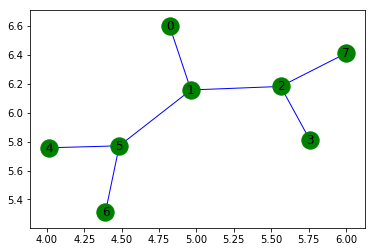

In [81]:
# Here it will draw same above point_list in neural way
goal = 7
mapping={0:'Start', 1:'1', 2:'2', 3:'3', 4:'4', 5:'5', 6:'6', 7:'7-Destination'} 
G=nx.Graph()
G.add_edges_from(points_list)
pos = nx.spring_layout(G,k=.5,center=points_list[2])  
nx.draw_networkx_nodes(G,pos,node_color='g')
nx.draw_networkx_edges(G,pos,edge_color='b')
nx.draw_networkx_labels(G,pos)
plt.show()

## 3. R Matrix : 
#### Create Matrix for number of points in the graph. In this case 8.

In [82]:
NO_OF_POINTS = 8

# create matrix x*y
R = np.matrix(np.ones(shape=(NO_OF_POINTS, NO_OF_POINTS)))
R *= -1
R

matrix([[-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1.]])

### 3.1 R Matrix Creation
#### Assign values to path and points so that optimal path is choosen
- INSTEAD OF MANUAL WE WILL USE LOOP to build R matrix

In [83]:
print("Point list", points_list)

print("Goal", goal)

# Here point[0]  is current (Y axis or row) point[1] is next step (X axis or col)
# assign 0 to paths and 150 to goal  point

for point in points_list:
    print(point)
    #print(point[1])
    #print(R[point[::-1]])
    
    if point[1] == goal:
        R[point] = 150
    else:
        R[point] = 0

    if point[0] == goal:
        
        R[point[::-1]] = 150
    else:
        # reverse of point
        R[point[::-1]]= 0

# add goal point round trip
R[goal,goal]= 150

R

Point list [(0, 1), (1, 5), (5, 6), (5, 4), (1, 2), (2, 3), (2, 7)]
Goal 7
(0, 1)
(1, 5)
(5, 6)
(5, 4)
(1, 2)
(2, 3)
(2, 7)


matrix([[ -1.,   0.,  -1.,  -1.,  -1.,  -1.,  -1.,  -1.],
        [  0.,  -1.,   0.,  -1.,  -1.,   0.,  -1.,  -1.],
        [ -1.,   0.,  -1.,   0.,  -1.,  -1.,  -1., 150.],
        [ -1.,  -1.,   0.,  -1.,  -1.,  -1.,  -1.,  -1.],
        [ -1.,  -1.,  -1.,  -1.,  -1.,   0.,  -1.,  -1.],
        [ -1.,   0.,  -1.,  -1.,   0.,  -1.,   0.,  -1.],
        [ -1.,  -1.,  -1.,  -1.,  -1.,   0.,  -1.,  -1.],
        [ -1.,  -1.,   0.,  -1.,  -1.,  -1.,  -1., 150.]])

> In the above matrix the y-axis is the state or where driver is currently located, and the x-axis is your possible next actions. We then build our Q-learning matrix which will hold all the lessons learned from our driver. The Q-learning model uses a transitional rule formula and gamma is the learning parameter

## 4. Q Matrix : 

> zero value Q matrix

> Created Q matrix same size as R matrix with value to 0

In [84]:
Q = np.matrix(np.zeros([NO_OF_POINTS,NO_OF_POINTS]))

# The learning parameter
gamma = 0.8

initial_state = 1

def available_actions(state):
    current_state_row = R[state,]
    av_act = np.where(current_state_row >= 0)[1]
    return av_act

available_act = available_actions(initial_state) 

def sample_next_action(available_actions_range):
    next_action = int(np.random.choice(available_act,1))
    return next_action

action = sample_next_action(available_act)

def update(current_state, action, gamma):
    
  max_index = np.where(Q[action,] == np.max(Q[action,]))[1]
  
  if max_index.shape[0] > 1:
      max_index = int(np.random.choice(max_index, size = 1))
  else:
      max_index = int(max_index)
  max_value = Q[action, max_index]
  
  Q[current_state, action] = R[current_state, action] + gamma * max_value
  #print('max_value', R[current_state, action] + gamma * max_value)
  
  if (np.max(Q) > 0):
    return(np.sum(Q/np.max(Q)*100))
  else:
    return (0)
    
update(initial_state, action, gamma)

0

### 4.1 Update the Q matrix by calling above all function

In [85]:
# Training
# Train over 700 iterations(Re-iterate the # process above),
#To update Q matrix, run this steps many times

scores = []
for i in range(700):
    current_state = np.random.randint(0, int(Q.shape[0]))
    available_act = available_actions(current_state)
    action = sample_next_action(available_act)
    score = update(current_state,action,gamma)
    scores.append(score)
    #print ('Score:', str(score))
    
print("Trained Q matrix:")
print(Q/np.max(Q)*100)



Trained Q matrix:
[[  0.          63.99950379   0.           0.           0.
    0.           0.           0.        ]
 [ 51.19960303   0.          80.           0.           0.
   51.19960303   0.           0.        ]
 [  0.          63.99950379   0.          63.99950379   0.
    0.           0.         100.        ]
 [  0.           0.          79.99937974   0.           0.
    0.           0.           0.        ]
 [  0.           0.           0.           0.           0.
   51.19960303   0.           0.        ]
 [  0.          63.99950379   0.           0.          40.93238724
    0.          40.958169     0.        ]
 [  0.           0.           0.           0.           0.
   51.19960303   0.           0.        ]
 [  0.           0.          79.99937974   0.           0.
    0.           0.          99.99922468]]


### 4.2 Testing 
 - Finding the optimal path by this below while loop from Q matrix

In [48]:
# Testing
current_state = 0 # Here we considered starting path as 0
steps = [current_state]

while current_state != 7:

    next_step_index = np.where(Q[current_state,] == np.max(Q[current_state,]))[1]
    
    if next_step_index.shape[0] > 1:
        next_step_index = int(np.random.choice(next_step_index, size = 1))
    else:
        next_step_index = int(next_step_index)
    
    steps.append(next_step_index)
    current_state = next_step_index
    
print("Most efficient path:")
print(steps)

Most efficient path:
[0, 1, 2, 7]


## 5. Conclusion
** Q1. How many iterations did it take to find the most efficient path? **

Most efficient path:
[0, 1, 3, 5]


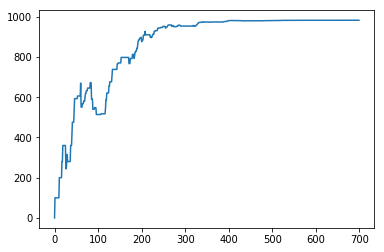

In [86]:
print("Most efficient path:")
print(steps)

plt.plot(scores)
plt.show()

> By Graph we can see around 300th iteration out of 700  it started to give optimal path (i.e score is constant)

<div class="alert alert-info" style="background-color:#001b63; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem 2:  Now from Point 0 to Point 6, total 7 steps</h2>
</div>


- Additional Exercise: Try the same for new path , now from Point 0 to Point 6. How many iterations will it take to find the efficient path

- Path to be tracked is 0,1,5,6

## 1. Data Set : 

In [104]:
# List of points to be depcited on the route
points_list = [(0,1), (1,5), (5,6), (5,4), (1,2), (2,3)]
points_list[2]

(5, 6)

## 2. Node Graph/Node chart : 

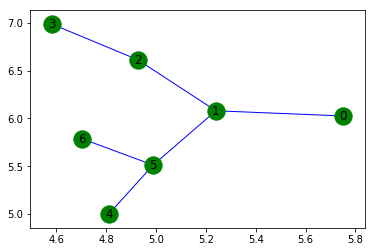

In [105]:
#### Drive has to go from point 0 to 6.  Let plot a node graph for the points with center=points_list[2] =>(5, 6)

goal = 6  # hERE 6 the is the Goal, based on that Neuro graph will change, 6 comes at the top
mapping={0:'Start', 1:'1', 2:'2', 3:'3', 4:'4', 5:'5', 6:'6-Destination'} 
G=nx.Graph()
G.add_edges_from(points_list)
pos = nx.spring_layout(G,k=.5,center=points_list[2])
nx.draw_networkx_nodes(G,pos,node_color='g')
nx.draw_networkx_edges(G,pos,edge_color='b')
nx.draw_networkx_labels(G,pos)
plt.show()

## 3. R Matrix : 
#### Create Matrix for number of points in the graph. In this case 7.

In [106]:
NO_OF_POINTS = 7

# create matrix x*y
R = np.matrix(np.ones(shape=(NO_OF_POINTS, NO_OF_POINTS)))
R *= -1
R

matrix([[-1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1.]])

### 3.1 R Matrix Creation
#### Assign values to path and points so that optimal path is choosen
- INSTEAD OF MANUAL WE WILL USE LOOP to build R matrix

In [107]:
# assign 0 to paths and 150 to goal  point
for point in points_list:
    print(point)
    if point[1] == goal:
        R[point] = 150
    else:
        R[point] = 0

    if point[0] == goal:
        R[point[::-1]] = 150
    else:
        # reverse of point
        R[point[::-1]]= 0

# add goal point round trip
R[goal,goal]= 150

R  # R matrix based on goal=6

(0, 1)
(1, 5)
(5, 6)
(5, 4)
(1, 2)
(2, 3)


matrix([[ -1.,   0.,  -1.,  -1.,  -1.,  -1.,  -1.],
        [  0.,  -1.,   0.,  -1.,  -1.,   0.,  -1.],
        [ -1.,   0.,  -1.,   0.,  -1.,  -1.,  -1.],
        [ -1.,  -1.,   0.,  -1.,  -1.,  -1.,  -1.],
        [ -1.,  -1.,  -1.,  -1.,  -1.,   0.,  -1.],
        [ -1.,   0.,  -1.,  -1.,   0.,  -1., 150.],
        [ -1.,  -1.,  -1.,  -1.,  -1.,   0., 150.]])

## 4. Q MATRIX

> zero value Q matrix

> Created Q matrix same size as R matrix with value to 0

In [108]:
Q = np.matrix(np.zeros([NO_OF_POINTS,NO_OF_POINTS]))

# The learning parameter
gamma = 0.8

initial_state = 1

def available_actions(state):
    current_state_row = R[state,]
    av_act = np.where(current_state_row >= 0)[1]
    return av_act

available_act = available_actions(initial_state) 

def sample_next_action(available_actions_range):
    next_action = int(np.random.choice(available_act,1))
    return next_action

action = sample_next_action(available_act)

def update(current_state, action, gamma):
    
  max_index = np.where(Q[action,] == np.max(Q[action,]))[1]
  
  if max_index.shape[0] > 1:
      max_index = int(np.random.choice(max_index, size = 1))
  else:
      max_index = int(max_index)
  max_value = Q[action, max_index]
  
  Q[current_state, action] = R[current_state, action] + gamma * max_value
  #print('max_value', R[current_state, action] + gamma * max_value)
  
  if (np.max(Q) > 0):
    return(np.sum(Q/np.max(Q)*100))
  else:
    return (0)
    
update(initial_state, action, gamma)

0

### 4.1 Update the Q matrix by calling above all function 

In [109]:
# Training
scores = []
for i in range(700):
    current_state = np.random.randint(0, int(Q.shape[0]))
    available_act = available_actions(current_state)
    action = sample_next_action(available_act)
    score = update(current_state,action,gamma)
    scores.append(score)
    #print ('Score:', str(score))
    
print("Trained Q matrix:")
print(Q/np.max(Q)*100)


Trained Q matrix:
[[  0.          63.99861193   0.           0.           0.
    0.           0.        ]
 [ 51.19686418   0.          51.19888954   0.           0.
   79.99826491   0.        ]
 [  0.          63.99861193   0.          40.95749134   0.
    0.           0.        ]
 [  0.           0.          51.19888954   0.           0.
    0.           0.        ]
 [  0.           0.           0.           0.           0.
   79.99988489   0.        ]
 [  0.          63.99861193   0.           0.          63.99861193
    0.         100.        ]
 [  0.           0.           0.           0.           0.
   80.          99.99985611]]


### 4.2 Testing 
 - Finding the optimal path by this below while loop from Q matrix

In [110]:
# Testing
current_state = 0 # Here we considered starting path as 0
steps = [current_state]

while current_state != 6:  # hERE 6 the is the end

    next_step_index = np.where(Q[current_state,] == np.max(Q[current_state,]))[1]
    
    if next_step_index.shape[0] > 1:
        next_step_index = int(np.random.choice(next_step_index, size = 1))
    else:
        next_step_index = int(next_step_index)
    
    steps.append(next_step_index)
    current_state = next_step_index
    
print("Most efficient path:")
print(steps)

Most efficient path:
[0, 1, 5, 6]


### Output [0,1,5,6] is here as expected above

## 5. Conclusion
** Q1. How many iterations did it take to find the most efficient path? **

Most efficient path:
[0, 1, 5, 6]


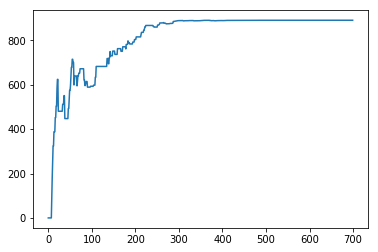

In [112]:
print("Most efficient path:")
print(steps)

plt.plot(scores)
plt.show()

> By Graph we can see around 250th iteration out of 700  it started to give optimal path (i.e score is constant)